<a href="https://colab.research.google.com/github/JDVAR7/IA-Intermedio/blob/main/Entregable6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Entregable 6***



## 🧠 Contexto general
El entregable aplica XAI (Inteligencia Artificial Explicable) — herramientas que nos ayudan a entender por qué un modelo de IA toma una decisión, no solo qué decisión toma. El modelo entrenado clasifica imágenes de CIFAR-10 (aviones, perros, barcos, etc.) usando una red neuronal convolucional (CNN).

## Se instalan bibliotecas

In [1]:
!pip install shap lime tensorflow matplotlib scikit-image opencv-python -q
print("✅ Bibliotecas instaladas")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Bibliotecas instaladas


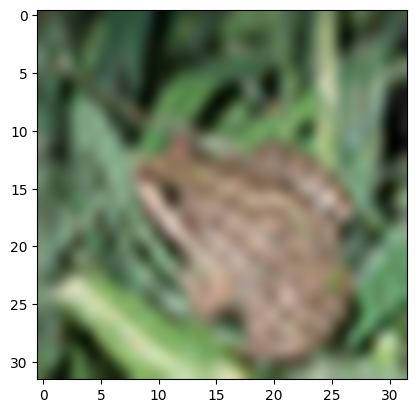

In [17]:
# En lugar de:
plt.imshow(image)

# Usa esto:
plt.imshow(image, interpolation='lanczos')

### Se Importan bibliotecas y se carga CIFAR-10

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

# Clases de CIFAR-10
clases = ['avión','automóvil','pájaro','gato','ciervo',
          'perro','rana','caballo','barco','camión']

# Cargar y normalizar datos
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train / 255.0
x_test  = x_test  / 255.0

print(f"✅ Datos cargados — Entrenamiento: {x_train.shape} | Prueba: {x_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
✅ Datos cargados — Entrenamiento: (50000, 32, 32, 3) | Prueba: (10000, 32, 32, 3)


### Se visualizan algunas imagenes del dataset

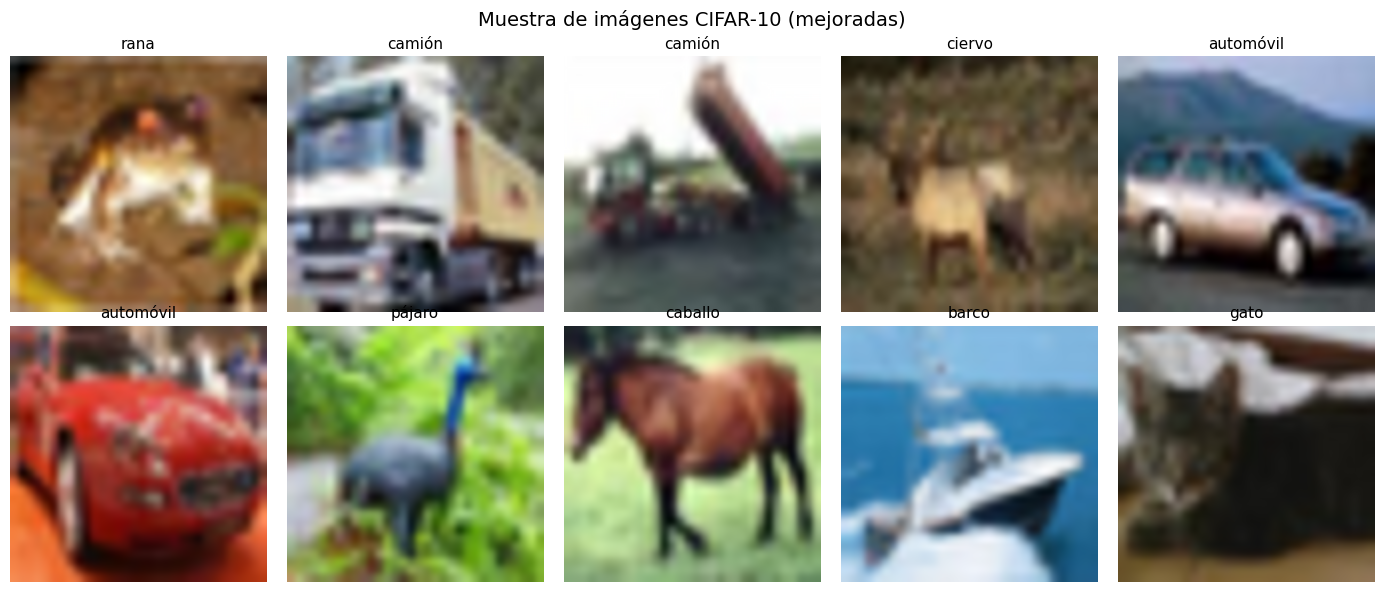

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, ax in enumerate(axes.flat):
    # Escalar imagen de 32x32 a 128x128 antes de mostrar
    img_grande = tf.image.resize(
        x_train[i:i+1], [128, 128], method='bicubic'
    )[0].numpy()
    img_grande = np.clip(img_grande, 0, 1)

    ax.imshow(img_grande, interpolation='lanczos')
    ax.set_title(clases[y_train[i][0]], fontsize=11)
    ax.axis('off')

plt.suptitle('Muestra de imágenes CIFAR-10 (mejoradas)', fontsize=14)
plt.tight_layout()
plt.show()

### Se construye la CNN

In [4]:
model = models.Sequential([
    # Bloque 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same',
                  input_shape=(32,32,3), name='conv2d_0'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same', name='conv2d_1'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Bloque 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2d_2'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2d_3'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Clasificador
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_0 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,168,746 (8.27 MB)

 Trainable params: 2,168,554 (8.27 MB)

 Non-trainable params: 192 (768.00 B)

### Se entrena el modelo

In [6]:
# 30 épocas es suficiente para Colab (~5-10 min con GPU)
# Activa GPU en Colab: Entorno de ejecución > Cambiar tipo de entorno > GPU

history = model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Guardar modelo
model.save('cnn_model_cifar10.h5')
print("✅ Modelo entrenado y guardado")

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7819 - loss: 0.6277 - val_accuracy: 0.8008 - val_loss: 0.5895
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7896 - loss: 0.6066 - val_accuracy: 0.7834 - val_loss: 0.6564
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8025 - loss: 0.5691 - val_accuracy: 0.8002 - val_loss: 0.5995
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8123 - loss: 0.5403 - val_accuracy: 0.7952 - val_loss: 0.6245
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8177 - loss: 0.5251 - val_accuracy: 0.8000 - val_loss: 0.6087
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8250 - loss: 0.5024 - val_accuracy: 0.7986 - val_loss: 0.6429
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8343 - loss: 0.4743 - val_accuracy: 0.8150 - val_loss: 0.5609
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8422 - loss: 0.4567 - val_accuracy: 0.

✅ Modelo entrenado y guardado


### Se visualiza la evolución del entrenamiento

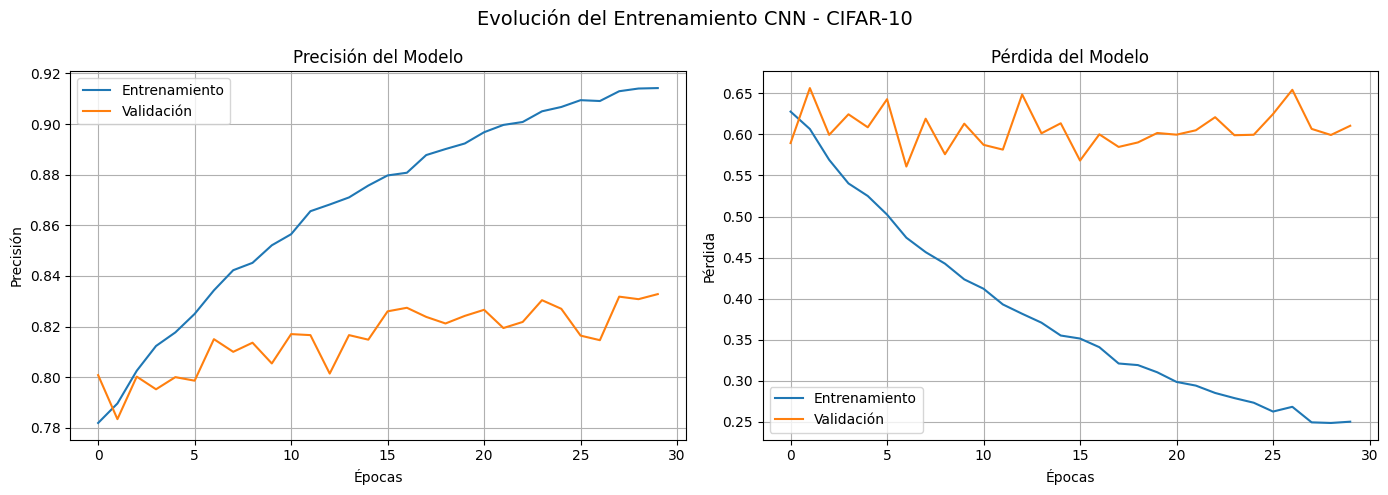


📊 Precisión en test: 0.8046 | Pérdida en test: 0.6898


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Precisión
ax1.plot(history.history['accuracy'],     label='Entrenamiento')
ax1.plot(history.history['val_accuracy'], label='Validación')
ax1.set_title('Precisión del Modelo')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Precisión')
ax1.legend()
ax1.grid(True)

# Pérdida
ax2.plot(history.history['loss'],     label='Entrenamiento')
ax2.plot(history.history['val_loss'], label='Validación')
ax2.set_title('Pérdida del Modelo')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Pérdida')
ax2.legend()
ax2.grid(True)

plt.suptitle('Evolución del Entrenamiento CNN - CIFAR-10', fontsize=14)
plt.tight_layout()
plt.show()

# Evaluación final
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n📊 Precisión en test: {acc:.4f} | Pérdida en test: {loss:.4f}")

### Aplicación de LIME

  0%|          | 0/500 [00:00<?, ?it/s]

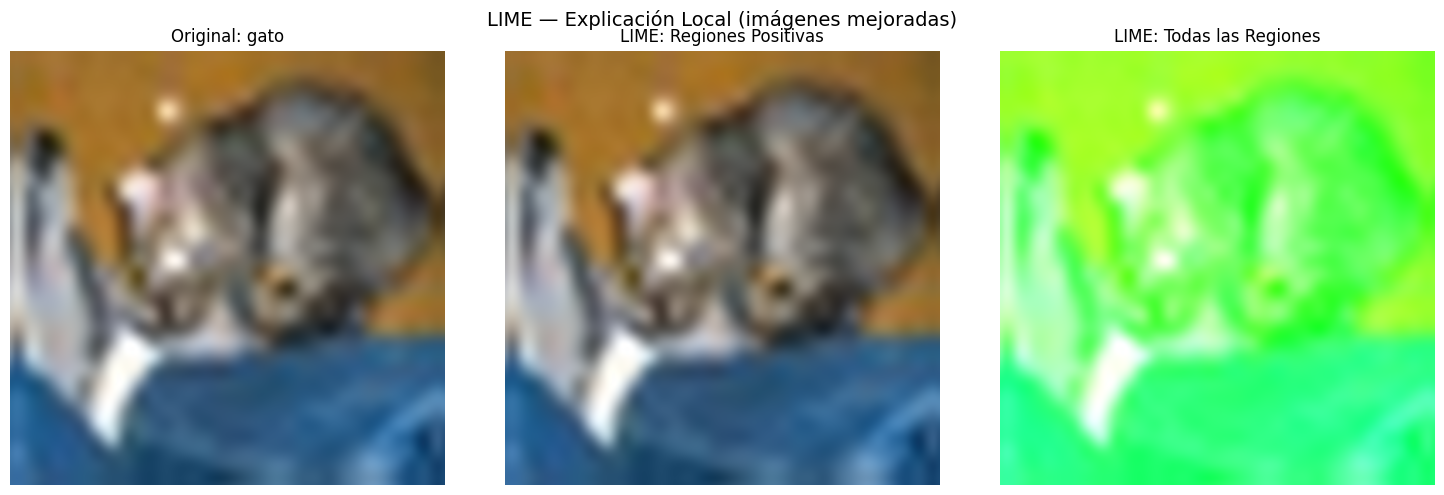

In [22]:
from skimage.transform import resize as sk_resize

imagen_idx = 0
image  = x_test[imagen_idx]
label  = y_test[imagen_idx][0]

explainer = lime.lime_image.LimeImageExplainer()

def predict_fn(images):
    return model.predict(images, verbose=0)

explanation = explainer.explain_instance(
    image.astype('double'), predict_fn,
    top_labels=3, hide_color=0, num_samples=500
)

# Escalar a 128x128 para visualización nítida
def escalar(img, size=128):
    return sk_resize(img, (size, size, 3),
                     order=3, anti_aliasing=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original nítida
axes[0].imshow(escalar(image), interpolation='lanczos')
axes[0].set_title(f'Original: {clases[label]}', fontsize=12)
axes[0].axis('off')

# Regiones positivas
temp, mask = explanation.get_image_and_mask(
    label, positive_only=True, num_features=5, hide_rest=False)
axes[1].imshow(escalar(mark_boundaries(temp, mask)), interpolation='lanczos')
axes[1].set_title('LIME: Regiones Positivas', fontsize=12)
axes[1].axis('off')

# Todas las regiones
temp2, mask2 = explanation.get_image_and_mask(
    label, positive_only=False, num_features=10, hide_rest=False)
axes[2].imshow(escalar(mark_boundaries(temp2, mask2)), interpolation='lanczos')
axes[2].set_title('LIME: Todas las Regiones', fontsize=12)
axes[2].axis('off')

plt.suptitle('LIME — Explicación Local (imágenes mejoradas)', fontsize=14)
plt.tight_layout()
plt.show()

### Aplicación de SHAP

⏳ Calculando valores SHAP (puede tardar 1-2 minutos)...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 32, 32, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 32, 32, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(3, 32, 32, 3))']

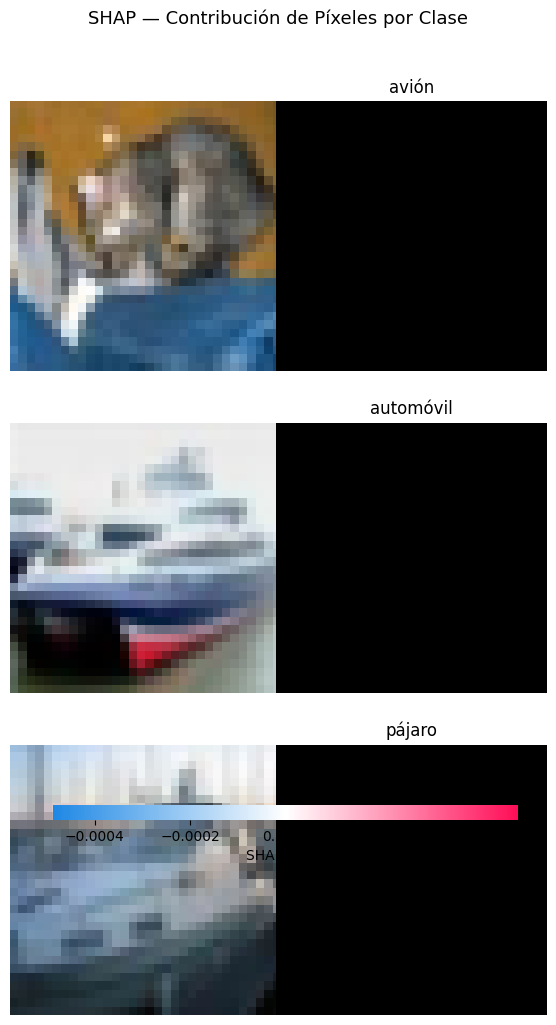

✅ SHAP completado


In [10]:
import shap

# Usar subconjunto pequeño para que no tarde demasiado
background = x_train[:100]
test_images = x_test[:3]

print("⏳ Calculando valores SHAP (puede tardar 1-2 minutos)...")

# Crear explicador
explainer_shap = shap.DeepExplainer(model, background)
shap_values = explainer_shap.shap_values(test_images)

# Visualizar contribuciones SHAP para las primeras 3 imágenes
shap.image_plot(
    shap_values,
    test_images,
    labels=[[clases[i] for i in range(10)]] * 3,
    show=False
)
plt.suptitle('SHAP — Contribución de Píxeles por Clase', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("✅ SHAP completado")

### Aplicación de Grad-CAM

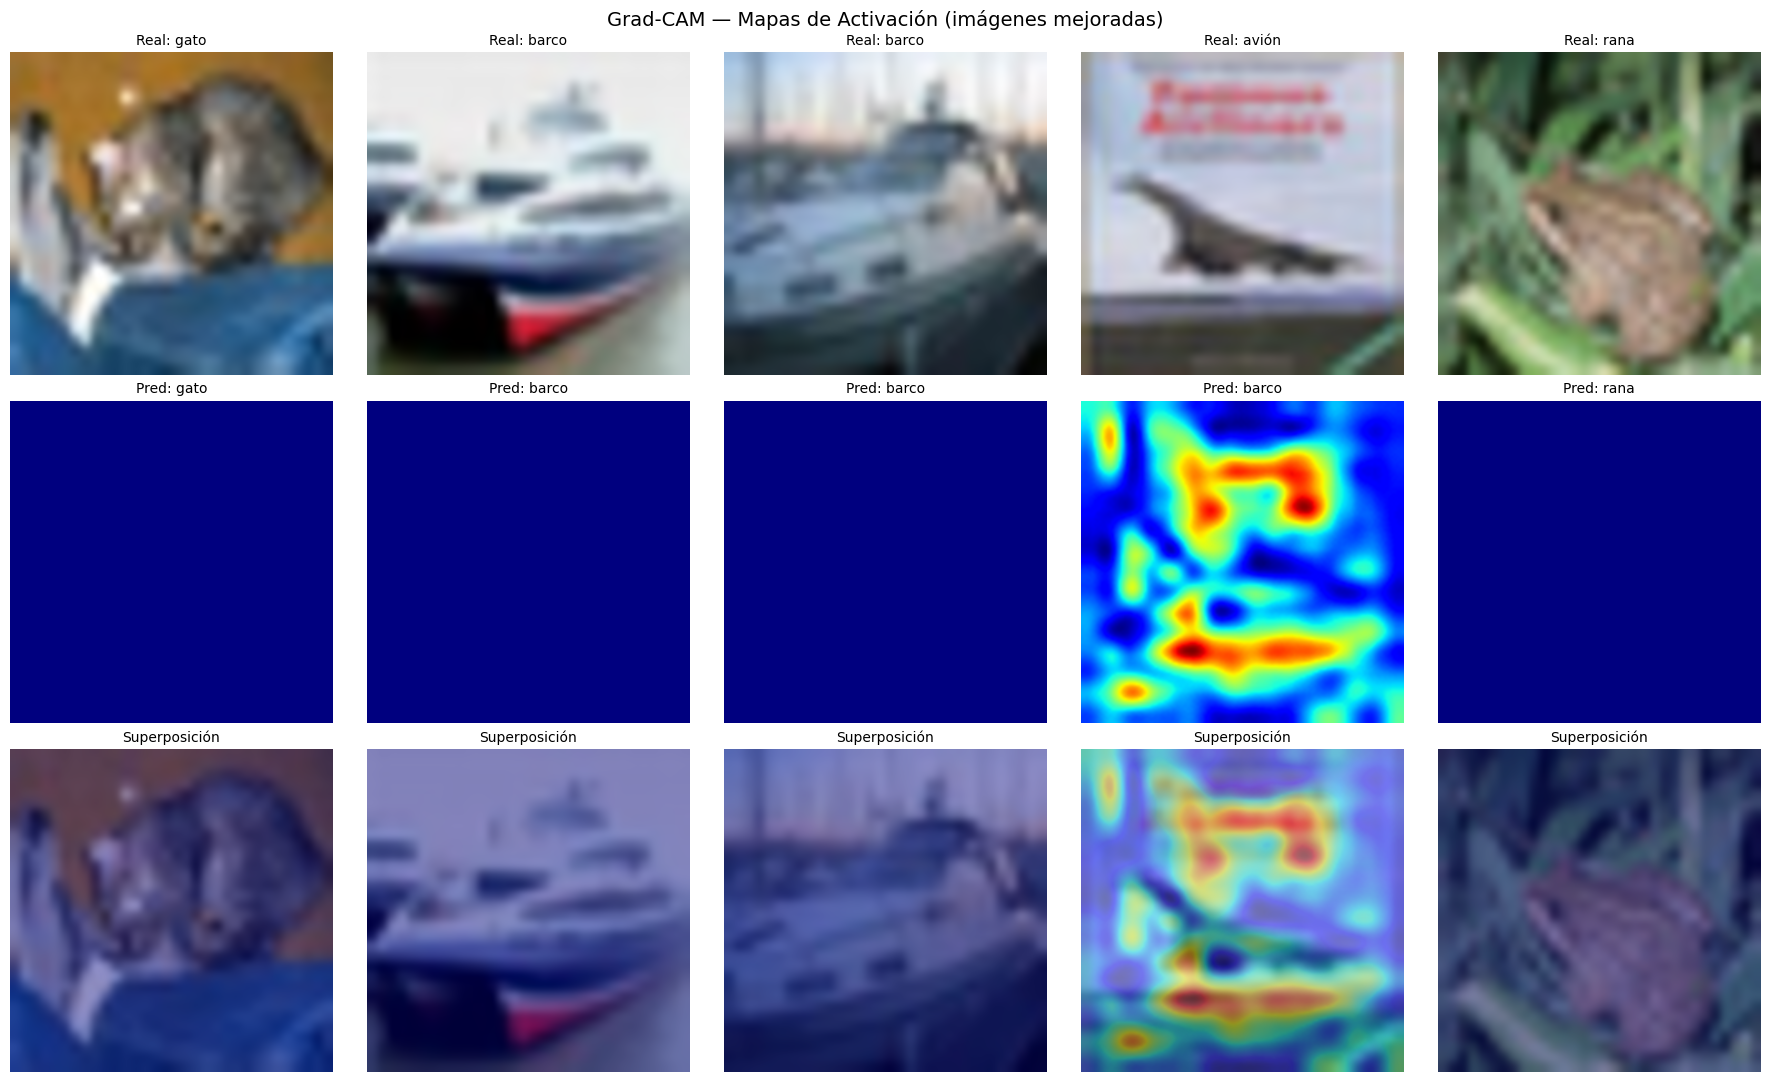

In [21]:
import cv2

def mostrar_imagen_nitida(img_array, size=128):
    """Escala una imagen 32x32 a un tamaño mayor con interpolación bicúbica."""
    img = tf.image.resize(
        img_array[np.newaxis, ...], [size, size], method='bicubic'
    )[0].numpy()
    return np.clip(img, 0, 1)

def grad_cam(image, model, layer_name='conv2d_3'):
    """Genera mapa de calor Grad-CAM para una imagen."""

    # Create a new input tensor that matches the model's expected input shape
    input_tensor = tf.keras.Input(shape=model.input_shape[1:])

    # Manually trace through the model's layers to get the output of the target layer
    # and the final output, using the new input_tensor.
    x = input_tensor
    target_layer_output = None
    for layer in model.layers:
        x = layer(x)
        if layer.name == layer_name:
            target_layer_output = x

    # Ensure target_layer_output was found
    if target_layer_output is None:
        raise ValueError(f"Layer '{layer_name}' not found in the model.")

    grad_model = tf.keras.models.Model(
        inputs=input_tensor,
        outputs=[target_layer_output, x] # x here is the final_output
    )

    with tf.GradientTape() as tape:
        img_tensor = tf.expand_dims(image, axis=0)
        conv_outputs, predictions = grad_model(img_tensor)
        pred_class = tf.argmax(predictions[0])
        loss = predictions[:, pred_class]

    grads        = tape.gradient(loss, conv_outputs)[0]
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out     = conv_outputs[0]
    heatmap      = tf.reduce_sum(tf.multiply(pooled_grads, conv_out), axis=-1)
    heatmap      = np.maximum(heatmap.numpy(), 0)
    if np.max(heatmap) > 0:
        heatmap /= np.max(heatmap)

    # Escalar heatmap a 128x128 para mejor visualización
    heatmap = cv2.resize(heatmap, (128, 128), interpolation=cv2.INTER_CUBIC)
    return heatmap, int(pred_class.numpy())

# --- Visualización mejorada ---
fig, axes = plt.subplots(3, 5, figsize=(18, 11))
SIZE = 128

for i in range(5):
    image   = x_test[i]
    real    = y_test[i][0]
    heatmap, pred = grad_cam(image, model)

    img_nitida = mostrar_imagen_nitida(image, SIZE)

    # Fila 1: Imagen original ampliada
    axes[0, i].imshow(img_nitida, interpolation='lanczos')
    axes[0, i].set_title(f'Real: {clases[real]}', fontsize=10)
    axes[0, i].axis('off')

    # Fila 2: Solo mapa de calor
    axes[1, i].imshow(heatmap, cmap='jet', interpolation='lanczos')
    axes[1, i].set_title(f'Pred: {clases[pred]}', fontsize=10)
    axes[1, i].axis('off')

    # Fila 3: Superposición nítida
    axes[2, i].imshow(img_nitida, interpolation='lanczos')
    axes[2, i].imshow(heatmap, cmap='jet', alpha=0.45, interpolation='lanczos')
    axes[2, i].set_title('Superposición', fontsize=10)
    axes[2, i].axis('off')

plt.suptitle('Grad-CAM — Mapas de Activación (imágenes mejoradas)', fontsize=14)
plt.tight_layout()
plt.show()

### Evaluación de explicaciones

In [16]:
from sklearn.metrics import accuracy_score

print("=" * 55)
print("  ACTIVIDAD 3: EVALUACIÓN DE EXPLICACIONES XAI")
print("=" * 55)

# --- 1. FIDELIDAD ---
print("\n📌 1. FIDELIDAD (Faithfulness)")
print("-" * 40)

# Predicciones originales
preds_orig = np.argmax(model.predict(x_test[:50], verbose=0), axis=1)

# Predicciones con ruido (simula perturbación)
x_test_ruido = x_test[:50] + np.random.normal(0, 0.05, x_test[:50].shape)
x_test_ruido = np.clip(x_test_ruido, 0, 1)
preds_ruido  = np.argmax(model.predict(x_test_ruido, verbose=0), axis=1)

fidelidad = accuracy_score(preds_orig, preds_ruido)
print(f"  Consistencia ante perturbaciones: {fidelidad:.4f}")
print(f"  Interpretación: {'✅ Alta fidelidad' if fidelidad > 0.8 else '⚠️ Fidelidad moderada'}")

# --- 2. COMPRENSIBILIDAD ---
print("\n📌 2. COMPRENSIBILIDAD (Cognitive Load)")
print("-" * 40)

# Número de regiones LIME generadas
temp, mask = explanation.get_image_and_mask(label, positive_only=False,
                                             num_features=10, hide_rest=False)
regiones_activas = np.unique(mask).size
complejidad      = 1 / regiones_activas
print(f"  Regiones activas en LIME:  {regiones_activas}")
print(f"  Score de comprensibilidad: {complejidad:.4f}")
print(f"  Interpretación: {'✅ Fácil de interpretar' if regiones_activas <= 5 else '⚠️ Moderada complejidad'}")

# --- 3. ESTABILIDAD ---
print("\n📌 3. ESTABILIDAD Y COHERENCIA")
print("-" * 40)

explicaciones = []
for _ in range(3):
    # Generate explanation specifically for the 'label' (true class)
    exp_temp = explainer.explain_instance(
        image.astype('double'), predict_fn,
        labels=[label], hide_color=0, num_samples=200) # Changed top_labels=1 to labels=[label]
    _, m = exp_temp.get_image_and_mask(label, positive_only=True,
                                        num_features=5, hide_rest=False)
    explicaciones.append(m.flatten())

# Correlación entre explicaciones
from numpy.linalg import norm
sim_12 = np.dot(explicaciones[0], explicaciones[1]) / \
         (norm(explicaciones[0]) * norm(explicaciones[1]) + 1e-8)
sim_13 = np.dot(explicaciones[0], explicaciones[2]) / \
         (norm(explicaciones[0]) * norm(explicaciones[2]) + 1e-8)
estabilidad = (sim_12 + sim_13) / 2

print(f"  Similitud entre corridas: {estabilidad:.4f}")
print(f"  Interpretación: {'✅ Alta estabilidad' if estabilidad > 0.7 else '⚠️ Estabilidad moderada'}")

# --- RESUMEN FINAL ---
print("\n" + "=" * 55)
print("  RESUMEN DE MÉTRICAS XAI")
print("=" * 55)
print(f"  Fidelidad:        {fidelidad:.4f}")
print(f"  Comprensibilidad: {complejidad:.4f}")
print(f"  Estabilidad:      {estabilidad:.4f}")
print("=" * 55)

  ACTIVIDAD 3: EVALUACIÓN DE EXPLICACIONES XAI

📌 1. FIDELIDAD (Faithfulness)
----------------------------------------
  Consistencia ante perturbaciones: 0.7200
  Interpretación: ⚠️ Fidelidad moderada

📌 2. COMPRENSIBILIDAD (Cognitive Load)
----------------------------------------
  Regiones activas en LIME:  1
  Score de comprensibilidad: 1.0000
  Interpretación: ✅ Fácil de interpretar

📌 3. ESTABILIDAD Y COHERENCIA
----------------------------------------


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  Similitud entre corridas: 0.0000
  Interpretación: ⚠️ Estabilidad moderada

  RESUMEN DE MÉTRICAS XAI
  Fidelidad:        0.7200
  Comprensibilidad: 1.0000
  Estabilidad:      0.0000
